In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

### Residuals

In [26]:
eid = "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b"

behave_dict = {}
for method in ['reduced_rank']:
    behave_dict[method] = {}
    gt, pred = [], []
    for beh in ["wheel-speed", "whisker-motion-energy"]:
        data = np.load(f"/burg/stats/users/yz4123/Downloads/ibl_unaligned/{eid}/{beh}/{method}/all/{eid}.npy", allow_pickle=True).item()
        test_y = data["test_y"].reshape(-1, 100, 1)
        test_pred = data["test_pred"].reshape(-1, 100, 1)
        gt.append(test_y)
        pred.append(test_pred)
    behave_dict[method]["gt"] = np.concatenate(gt, axis=-1)
    behave_dict[method]["pred"] = np.concatenate(pred, axis=-1)
    behave_dict[method]["trial-avg-gt"] = np.mean(behave_dict[method]["gt"], 0)
    behave_dict[method]["trial-avg-pred"] = np.mean(behave_dict[method]["pred"], 0)
    behave_dict[method]["single-trial-gt"] = behave_dict[method]["gt"] - behave_dict[method]["trial-avg-gt"]
    behave_dict[method]["single-trial-pred"] = behave_dict[method]["pred"] - behave_dict[method]["trial-avg-pred"]
    behave_dict[method]["trial-avg-resid"] = behave_dict[method]["trial-avg-gt"] - behave_dict[method]["trial-avg-pred"]
    behave_dict[method]["single-trial-resid"] = behave_dict[method]["single-trial-gt"] - behave_dict[method]["single-trial-pred"]
    behave_dict[method]["single-trial-resid"] = (behave_dict[method]["single-trial-resid"] - behave_dict[method]["single-trial-resid"].mean(0)) / behave_dict[method]["single-trial-resid"].std(0)

In [ ]:
n_trials = len(behave_dict["reduced_rank"]["gt"])
n_time = 100

fig, axes = plt.subplots(1, 2, figsize=(6, 2))
axes[0].scatter(
    behave_dict[method]["single-trial-gt"][...,0].mean(1), 
    behave_dict[method]["single-trial-pred"][...,0].mean(1), s=2, c="dodgerblue"
)
axes[0].plot([-0.5, 2], [-0.5, 2], color="black")
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")

for i in range(50):
    axes[1].scatter(np.arange(n_time), behave_dict["reduced_rank"]["single-trial-resid"][i,...,0], color="dodgerblue", s=.1)

axes[1].set_ylim(-5, 10)
axes[1].set_xticklabels(["", "-0.5", "0", "time (s)", "1", "1.5"])
axes[1].set_ylabel("Residual \n(Observed - Predicted)")
plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/wheel_resids.png', dpi=400)
plt.show()


In [ ]:
n_trials = len(behave_dict["reduced_rank"]["gt"])
n_time = 100

fig, axes = plt.subplots(1, 2, figsize=(6, 2))
axes[0].scatter(
    behave_dict[method]["single-trial-gt"][...,1].mean(1), 
    behave_dict[method]["single-trial-pred"][...,1].mean(1), s=2, c="dodgerblue"
)
axes[0].plot([-3, 4], [-3, 4], color="black")
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")

for i in range(50):
    axes[1].scatter(np.arange(n_time), behave_dict["reduced_rank"]["single-trial-resid"][i,...,1], color="dodgerblue", s=.1)

axes[1].set_ylim(-5, 10)
axes[1].set_xticklabels(["", "-0.5", "0", "time (s)", "1", "1.5"])
axes[1].set_ylabel("Residual \n(Observed - Predicted)")
plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/whisker_resids.png', dpi=400)
plt.show()

### Statistical Analysis of ARI

#### Single Session

In [113]:
import torch
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from models.decoders import ReducedRankDecoder, MultiSessionReducedRankDecoder
from utils.data_loader_utils import SingleSessionDataModule, MultiSessionDataModule
from utils.config_utils import config_from_kwargs, update_config

In [3]:
base_path = "/burg/stats/users/yz4123/Downloads/"

OUTPUT_SIZE_LOOKUP = {"choice": 2}
LENGTH_LOOKUP = {"choice": 2.}

kwargs = {"model": f"include:{base_path.replace('Downloads', 'neural_decoding')}/src/configs/decoder.yaml"}
config = config_from_kwargs(kwargs)
config = update_config(f"{base_path.replace('Downloads', 'neural_decoding')}/src/configs/decoder.yaml", config)
config = update_config(f"{base_path.replace('Downloads', 'neural_decoding')}/src/configs/clf_trainer.yaml", config)

session_id = "56b57c38-2699-4091-90a8-aba35103155e"
target = "choice"
best_model_path = Path(base_path)/"checkpoints"/session_id/target/"reduced_rank"/"all"
ckpt_name = list(best_model_path.glob("*.ckpt"))[0]
best_model_path = best_model_path/ckpt_name

config["eid"] = session_id
config["target"] = target
config["length"] = LENGTH_LOOKUP[target]
config["model"]["output_size"] = OUTPUT_SIZE_LOOKUP[target]
config["region"] = "all"
config["training"]["device"] = torch.device("cpu")
config["dirs"]["data_dir"] = Path(base_path)/config.dirs.data_dir
config["data"]["use_nlb"] = False
config["data"]["bin_size"] = 20
config['reduced_rank']['temporal_rank'] = 3

In [99]:
# Load data
dm = SingleSessionDataModule(config)
dm.update_config()
dm.setup()
train_dataset, test_dataset = dm.train, dm.test

config["training"]["total_steps"] = dm.config["training"]["num_epochs"] * len(dm.train)

# Load model
model = ReducedRankDecoder.load_from_checkpoint(
    best_model_path,
    config=config
)
print(model.U.shape, model.V.shape)

train_x, train_y = [], []
for (x, y, region, eid) in train_dataset:
    train_x.append(x)
    train_y.append(y)

test_x, test_y = [], []
for (x, y, region, eid) in test_dataset:
    test_x.append(x)
    test_y.append(y)

train_x, train_y = torch.stack(train_x), torch.stack(train_y)
test_x, test_y = torch.stack(test_x), torch.stack(test_y)

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

In [103]:
latents = ((test_x @ model.U) * model.V.mean(-1).T.unsqueeze(0)).detach().numpy()
labels = test_y.numpy().argmax(-1).astype(int)
print(latents.shape)

from scipy.ndimage import gaussian_filter1d
sigma = 3.
smoothed_latents = np.zeros_like(latents)

for i in range(latents.shape[0]):
    for j in range(latents.shape[-1]):
        smoothed_latents[i, :, j] = gaussian_filter1d(latents[i, :, j], sigma=sigma) 

(101, 100, 3)


In [105]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

X = smoothed_latents.reshape(len(smoothed_latents), -1) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
print(adjusted_rand_score(labels, cluster_labels))

0.4336475285595136


#### Multi-Session

In [111]:
base_path = "/burg/stats/users/yz4123/Downloads/"

OUTPUT_SIZE_LOOKUP = {"choice": 2}
LENGTH_LOOKUP = {"choice": 2.}

kwargs = {"model": f"include:{base_path.replace('Downloads', 'neural_decoding')}/src/configs/decoder.yaml"}
config = config_from_kwargs(kwargs)
config = update_config(f"{base_path.replace('Downloads', 'neural_decoding')}/src/configs/decoder.yaml", config)
config = update_config(f"{base_path.replace('Downloads', 'neural_decoding')}/src/configs/clf_trainer.yaml", config)

session_id = "multi-session"
target = "choice"
best_model_path = Path(base_path)/"checkpoints"/session_id/target/"reduced_rank"/"all"
ckpt_name = list(best_model_path.glob("*.ckpt"))[0]
best_model_path = best_model_path/ckpt_name

with open(Path(base_path.replace('Downloads', 'neural_decoding'))/'data/region_session_ids.txt', 'r') as f:
    eids = f.read().splitlines()  # removes newlines
    eids = [eid.strip() for eid in eids if eid.strip()]

config["target"] = target
config["length"] = LENGTH_LOOKUP[target]
config["model"]["output_size"] = OUTPUT_SIZE_LOOKUP[target]
config["region"] = "all"
config["training"]["device"] = torch.device("cpu")
config["dirs"]["data_dir"] = Path(base_path)/config.dirs.data_dir
config["data"]["use_nlb"] = False
config["data"]["bin_size"] = 20
config['reduced_rank']['temporal_rank'] = 3
_config = config.copy()

In [114]:
configs = []
for eid in eids:
    config = _config.copy()
    config["eid"] = eid
    configs.append(config)

dm = MultiSessionDataModule(eids, configs)
dm.update_config()
dm.setup()

config = dm.configs[0].copy()
config["n_units"] = [_config["n_units"] for _config in dm.configs]
config["eid_to_indx"] = {e: i for i, e in enumerate(eids)}

num_train = 0
for _train_loader in dm.train:
    num_train += len(_train_loader) * config["training"]["batch_size"]

config["training"]["total_steps"] = config["training"]["num_epochs"] * num_train

# Load model
model = MultiSessionReducedRankDecoder.load_from_checkpoint(
    best_model_path,
    config=config
)

In [117]:
train_dataset, test_dataset = dm.train, dm.test

In [182]:
eid = "56b57c38-2699-4091-90a8-aba35103155e"
eid_idx = config["eid_to_indx"][eid]

In [183]:
train, test = train_dataset[eid_idx], test_dataset[eid_idx]

train_x, train_y = [], []
for (x, y, region, eid) in train:
    for idx in range(x.shape[0]):
        train_x.append(x[idx].cpu())
        train_y.append(y[idx].cpu())

test_x, test_y = [], []
for (x, y, region, eid) in test:
    for idx in range(x.shape[0]):
        test_x.append(x[idx].cpu())
        test_y.append(y[idx].cpu())
train_x, train_y = torch.stack(train_x), torch.stack(train_y)
test_x, test_y = torch.stack(test_x), np.stack(test_y)

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

torch.Size([352, 100, 2220]) torch.Size([352, 2])
torch.Size([101, 100, 2220]) (101, 2)


In [184]:
latents = ((test_x @ model.Us[eid_idx]) * model.V.mean(-1).T.unsqueeze(0)).detach().numpy()
labels = test_y.argmax(-1).astype(int)
print(latents.shape)

from scipy.ndimage import gaussian_filter1d
sigma = 3.
smoothed_latents = np.zeros_like(latents)

for i in range(latents.shape[0]):
    for j in range(latents.shape[-1]):
        smoothed_latents[i, :, j] = gaussian_filter1d(latents[i, :, j], sigma=sigma) 

(101, 100, 3)


In [185]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

X = smoothed_latents.reshape(len(smoothed_latents), -1) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
print(adjusted_rand_score(labels, cluster_labels))

0.4085451340731373


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Data as four lists
session_ids = [
    "572a95d1-39ca-42e1-8424-5c9ffcb2df87",
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "d23a44ef-1402-4ed7-97f5-47e9a7a504d9",
    "d2832a38-27f6-452d-91d6-af72d794136c",
    "8928f98a-b411-497e-aa4b-aa752434686d",
    "61e11a11-ab65-48fb-ae08-3cb80662e5d6",
    "b03fbc44-3d8e-4a6c-8a50-5ea3498568e0",
    "15b69921-d471-4ded-8814-2adad954bcd8",
    "b196a2ad-511b-4e90-ac99-b5a29ad25c22",
    "56b57c38-2699-4091-90a8-aba35103155e"
]

single_ari = [
    0.40569, 0.51100, 0.42608, 0.53063, 0.60783,
    0.34480, 0.63028, 0.42221, 0.50867, 0.40855
]

single_acc = [
    0.70370, 0.90244, 0.88889, 0.84426, 0.95161,
    0.95313, 0.83636, 0.88591, 0.80435, 0.90099
]

multi_ari = [
    0.51369, 0.52802, 0.45695, 0.61970, 0.62294,
    0.45589, 0.67125, 0.44596, 0.50317, 0.43365
]

multi_acc = [
    0.75926, 0.91870, 0.88889, 0.84426, 0.97581,
    0.96094, 0.87273, 0.89262, 0.80435, 0.91089
]

# Convert to numpy arrays
single_ari = np.array(single_ari)
single_acc = np.array(single_acc)
multi_ari = np.array(multi_ari)
multi_acc = np.array(multi_acc)

In [9]:
(multi_acc.mean() - single_acc.mean()) / single_acc.mean()

0.018083084629896932

In [10]:
(multi_ari.mean() - single_ari.mean()) / single_ari.mean()

0.09497595782923994

/local/ipykernel_3421608/3446080565.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/effect_size_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3421608/3446080565.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/effect_size_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3421608/3446080565.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/effect_size_compari

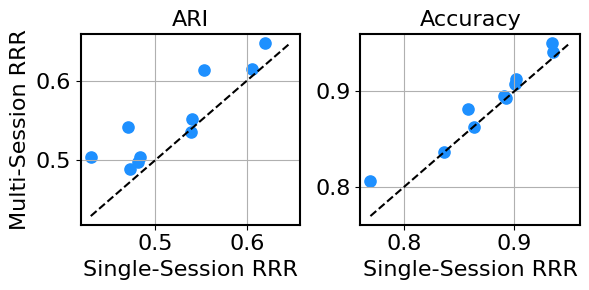

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

font_properties = {'fontsize': 12, 'fontweight': 'bold', 'family': 'serif'}

titles = ["ARI", "Accuracy"]
data = [(single_ari, multi_ari), (single_acc, multi_acc)]
colors = ['dodgerblue', 'dodgerblue']

for ax_i, (ax, (x, y), title, color) in enumerate(zip(axes.flat, data, titles, colors)):
    ax.scatter(x, y, color='dodgerblue', s=65)

    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))

    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
    
    ax.set_title(title, fontsize=16)
    
    if ax_i == 0:
      ax.set_ylabel("Multi-Session RRR", fontsize=16)

    ax.set_xlabel("Single-Session RRR", fontsize=16)
    ax.grid(True)

    if ax_i == 0:
      ax.set_xticks([0.45, 0.60])
      ax.set_yticks([0.45, 0.60])
    if ax_i == 1:
      ax.set_xticks([0.75, 0.90])
      ax.set_yticks([0.75, 0.90])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/effect_size_comparison.png', dpi=400, bbox_inches='tight')
plt.show()

/local/ipykernel_105888/2931045148.py:127: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ari_acc_diff.png', dpi=600)
/local/ipykernel_105888/2931045148.py:127: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ari_acc_diff.png', dpi=600)
/local/ipykernel_105888/2931045148.py:127: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ari_acc_diff.png', dpi=600)
/local/ipykernel_105888/2931045148.py:127: Matplotlib

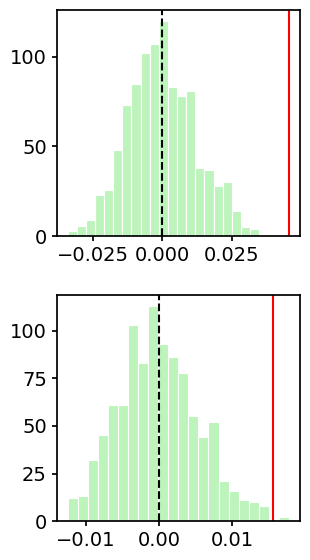


Bootstrap Paired T-Test Results:

ARI Difference (Multi - Single):
Mean difference: 0.04555
95% CI: [0.02206, 0.07036]
p-value: 0.00000

Accuracy Difference (Multi - Single):
Mean difference: 0.01568
95% CI: [0.00606, 0.02715]
p-value: 0.00200


In [9]:
# Paired differences
ari_diff = multi_ari - single_ari
acc_diff = multi_acc - single_acc

def bootstrap_paired_ttest(x1, x2, n_bootstrap=1000, alpha=0.05):
    """
    Perform paired bootstrap t-test between two related samples.
    
    Args:
        x1, x2: Arrays of paired observations
        n_bootstrap: Number of bootstrap iterations
        alpha: Significance level for confidence intervals
    """
    n = len(x1)
    observed_diff = np.mean(x2 - x1)
    
    # Center the differences around 0 (null hypothesis)
    diffs = x2 - x1
    centered_diffs = diffs - np.mean(diffs)
    
    # Generate bootstrap samples
    bootstrap_diffs = []
    for _ in range(n_bootstrap):
        # Sample indices with replacement
        indices = np.random.choice(n, size=n, replace=True)
        # Calculate mean difference for this bootstrap sample
        bootstrap_diffs.append(np.mean(centered_diffs[indices]))
    
    bootstrap_diffs = np.array(bootstrap_diffs)
    
    # Calculate confidence interval
    ci_lower = np.percentile(bootstrap_diffs, alpha/2 * 100) + observed_diff
    ci_upper = np.percentile(bootstrap_diffs, (1 - alpha/2) * 100) + observed_diff
    
    # Calculate two-sided p-value
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    
    return observed_diff, ci_lower, ci_upper, p_value, bootstrap_diffs

# Run bootstrap paired t-test for both metrics
ari_diff, ari_ci_lower, ari_ci_upper, ari_p_value, ari_bootstrap_diffs = bootstrap_paired_ttest(
    np.array(single_ari), 
    np.array(multi_ari)
)

acc_diff, acc_ci_lower, acc_ci_upper, acc_p_value, acc_bootstrap_diffs = bootstrap_paired_ttest(
    np.array(single_acc), 
    np.array(multi_acc)
)

plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.25
plt.rcParams['xtick.major.width'] = 1.25
plt.rcParams['ytick.major.width'] = 1.25
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Create distribution plots for bootstrap differences
plt.figure(figsize=(3.5, 6))

# ARI difference distribution
plt.subplot(2, 1, 1)
sns.histplot(ari_bootstrap_diffs, kde=False, color='lightgreen', edgecolor='white', alpha=0.6)
plt.axvline(0, color='k', linestyle='--', label='Null hypothesis')
plt.axvline(ari_diff, color='r', linestyle='-', label='Observed difference')
plt.ylabel('')
# plt.title(f'ARI Difference Bootstrap (p={ari_p_value:.5f})')
# plt.xlabel('Difference (centered at 0)')
# plt.legend()

# Accuracy difference distribution
plt.subplot(2, 1, 2)
sns.histplot(acc_bootstrap_diffs, kde=False, color='lightgreen', edgecolor='white', alpha=0.6)
plt.axvline(0, color='k', linestyle='--', label='Null hypothesis')
plt.axvline(acc_diff, color='r', linestyle='-', label='Observed difference')
# plt.title(f'Accuracy Difference Bootstrap (p={acc_p_value:.5f})')
# plt.xlabel('Difference (centered at 0)')
plt.ylabel('')
# plt.legend()

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ari_acc_diff.png', dpi=600)

plt.show()

# Print results
print("\nBootstrap Paired T-Test Results:")
print("\nARI Difference (Multi - Single):")
print(f"Mean difference: {ari_diff:.5f}")
print(f"95% CI: [{ari_ci_lower:.5f}, {ari_ci_upper:.5f}]")
print(f"p-value: {ari_p_value:.5f}")

print("\nAccuracy Difference (Multi - Single):")
print(f"Mean difference: {acc_diff:.5f}")
print(f"95% CI: [{acc_ci_lower:.5f}, {acc_ci_upper:.5f}]")
print(f"p-value: {acc_p_value:.5f}")


### PCA-Fourier Correlation

In [2]:
eid = "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b"

behave_dict = {}
for method in ['reduced_rank']:
    behave_dict[method] = {}
    gt, pred = [], []
    for beh in ["wheel-speed", "whisker-motion-energy"]:
        data = np.load(f"/burg/stats/users/yz4123/Downloads/ibl_unaligned/{eid}/{beh}/{method}/all/{eid}.npy", allow_pickle=True).item()
        test_y = data["test_y"].reshape(-1, 100, 1)
        test_pred = data["test_pred"].reshape(-1, 100, 1)
        gt.append(test_y)
        pred.append(test_pred)
    behave_dict[method]["gt"] = np.concatenate(gt, axis=-1)

/local/ipykernel_4143843/1156919577.py:74: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/pca_fourier_corr_whisker.png', dpi=600)
/local/ipykernel_4143843/1156919577.py:74: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/pca_fourier_corr_whisker.png', dpi=600)
/local/ipykernel_4143843/1156919577.py:74: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/pca_fourier_corr_whisker.png', dpi=600)
/local/ipykernel_

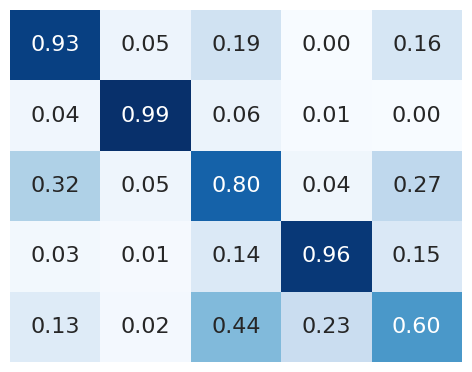

In [40]:
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

def compute_fourier_basis(n_timepoints, n_components):
    """Compute Fourier basis functions."""
    t = np.linspace(0, 2*np.pi, n_timepoints)
    basis = []
    
    # Add DC component (constant)
    basis.append(np.ones(n_timepoints) / np.sqrt(n_timepoints))
    
    # Add sine and cosine components
    for i in range(1, (n_components + 1) // 2):
        basis.append(np.sin(i * t) / np.sqrt(n_timepoints/2))
        basis.append(np.cos(i * t) / np.sqrt(n_timepoints/2))
    
    # If n_components is odd, add the final sine component
    if n_components % 2 == 1:
        i = (n_components + 1) // 2
        basis.append(np.sin(i * t) / np.sqrt(n_timepoints/2))
    
    return np.array(basis)

# Assuming behavior has shape (K, 100)
behavior = behave_dict["reduced_rank"]["gt"][...,1]
K, n_timepoints = behavior.shape
n_components = 6  # Number of components to analyze

# Center the data
behavior_centered = behavior - behavior.mean(axis=0)

# Compute PCs
pca = PCA(n_components=n_components)
pcs = pca.fit_transform(behavior_centered)
pc_components = pca.components_  # Shape: (n_components, n_timepoints)

# Compute Fourier basis
fourier_basis = compute_fourier_basis(n_timepoints, n_components+1)  # Shape: (n_components, n_timepoints)

# Compute similarity matrix (correlation between each PC and Fourier component)
similarity = np.zeros((n_components, n_components))
for i in range(n_components):
    for j in range(n_components):
        correlation = np.corrcoef(pc_components[i], fourier_basis[j])[0,1]
        similarity[i,j] = abs(correlation)  # Use absolute correlation

plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1

# Create heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(similarity[1:,1:], 
            cmap='Blues', 
            xticklabels=[f'F{i+1}' for i in range(n_components-1)],
            yticklabels=[f'PC{i+1}' for i in range(n_components-1)],
            annot=True,  # Show numerical values
            fmt='.2f',   # Format to 2 decimal places
            cbar=False)

# Make axis lines thicker
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(2)  # Increase line width of all spines


ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
# plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/pca_fourier_corr_whisker.png', dpi=600)
plt.show()

### Rank Analysis

In [24]:
# Create dictionaries for each type
gabors_data = {
    '715093703': [0.50068, 0.50754, 0.52675, 0.50754],
    '719161530': [0.48122, 0.47983, 0.47705, 0.46592],
    '721123822': [0.65432, 0.65432, 0.65432, 0.65569],
    '732592105': [0.53635, 0.53361, 0.53086, 0.53086],
    '737581020': [0.47325, 0.47874, 0.50754, 0.48560],
    '739448407': [0.47050, 0.42661, 0.48011, 0.44582],
    '742951821': [0.47873, 0.47188, 0.47737, 0.48148],
    '743475441': [0.46364, 0.47325, 0.44856, 0.41975],
    '744228101': [0.46090, 0.43073, 0.44033, 0.39918],
    '746083955': [0.48834, 0.47325, 0.50069, 0.49931]
}

static_gratings_data = {
    '715093703': [0.72547, 0.79776, 0.80551, 0.78916],
    '719161530': [0.69568, 0.74914, 0.72845, 0.74483],
    '721123822': [0.72068, 0.72931, 0.73793, 0.75086],
    '732592105': [0.75968, 0.78984, 0.78553, 0.79156],
    '737581020': [0.68533, 0.74933, 0.76089, 0.76444],
    '739448407': [0.71575, 0.78006, 0.75582, 0.77540],
    '742951821': [0.62101, 0.64513, 0.64341, 0.66236],
    '743475441': [0.56072, 0.60465, 0.64686, 0.64944],
    '744228101': [0.51593, 0.56417, 0.59690, 0.59345],
    '746083955': [0.72523, 0.78725, 0.79070, 0.77950]
}

running_speed_data = {
    '715093703': [0.65419, 0.62121, 0.65352, 0.63959],
    '719161530': [0.81828, 0.86470, 0.86202, 0.85784],
    '721123822': [0.87231, 0.87964, 0.87518, 0.88214],
    '732592105': [0.76080, 0.75804, 0.74735, 0.74533],
    '737581020': [0.82936, 0.79610, 0.80824, 0.79927],
    '739448407': [0.17073, 0.29569, 0.23239, 0.27369],
    '742951821': [-0.36264, -0.32889, -0.33770, -0.35062],
    '743475441': [0.10701, -0.11580, -0.04972, -0.06120],
    '744228101': [0.70335, 0.77486, 0.76528, 0.76130],
    '746083955': [0.72624, 0.73379, 0.72567, 0.71421]
}

# Create empty lists to store the data
ranks = []
metrics = []
types = []
sessions = []

# Ranks used
rank_values = [2, 5, 10, 15]

# Process each dataset
for session_id, values in gabors_data.items():
    ranks.extend(rank_values)
    metrics.extend(values)
    types.extend(['Gabors'] * 4)
    sessions.extend([session_id] * 4)

for session_id, values in static_gratings_data.items():
    ranks.extend(rank_values)
    metrics.extend(values)
    types.extend(['Static Gratings'] * 4)
    sessions.extend([session_id] * 4)

for session_id, values in running_speed_data.items():
    ranks.extend(rank_values)
    metrics.extend(values)
    types.extend(['Running Speed'] * 4)
    sessions.extend([session_id] * 4)

# Create the DataFrame
combined_df = pd.DataFrame({
    'Rank': ranks,
    'Metric': metrics,
    'Type': types,
    'Session': sessions
})

/local/ipykernel_105888/3797595010.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/local/ipykernel_105888/3797595010.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


<Figure size 800x1200 with 0 Axes>

/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11

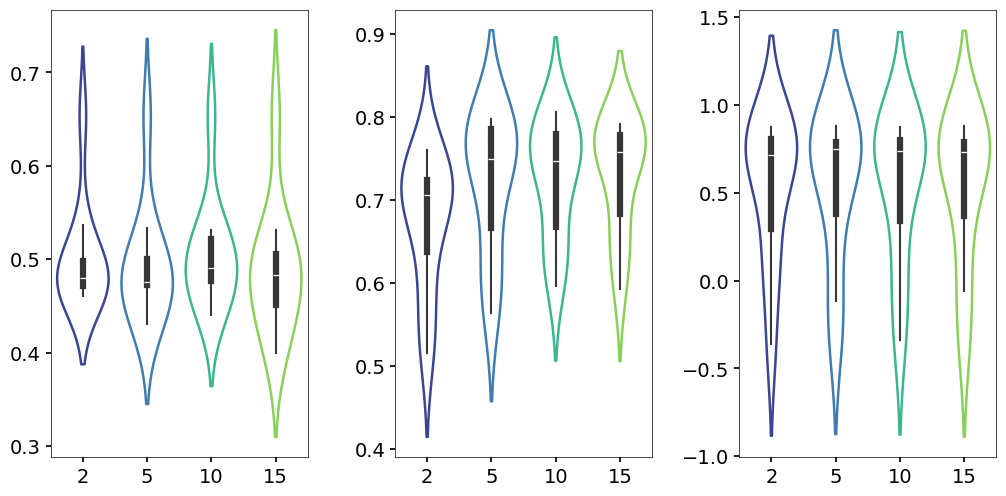

In [86]:
# Define the colors to match the gradient from purple to green
# colors = ['#4C3CDA', '#3E7DB3', '#3AB78F', '#88D158']

colors = ['#3B4595', '#3E7DB3', '#3AB78F', '#88D158']

# n_colors = 4
# colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

# Recreate the plot in the same style as the reference image (violin plots with split panels)
plt.figure(figsize=(8, 12))
g = sns.catplot(
    data=combined_df,
    x="Rank", 
    y="Metric",
    col="Type", 
    kind="violin",
    height=6, 
    aspect=0.6,
    sharey=False, 
    inner="box",
    linewidth=1., 
    # width=1.,
    palette="viridis",
    scale='width', 
)

# Customize each violin plot
for i, ax in enumerate(g.axes[0]):
    # Get all violins in the current subplot
    violins = ax.collections
    for j, violin in enumerate(violins):
        violin.set_facecolor('none')  # Make inside transparent
        violin.set_edgecolor(colors[j])  # Set edge color from your palette
        violin.set_linewidth(1.8)  

for i, ax in enumerate(g.axes[0]):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(.5)
        spine.set_color('black')

    # ax.tick_params(length=0)  # Set tick length to 0
    # ax.set_xticks([])  # Remove x-axis ticks
    # ax.set_yticks([])  # Remove y-axis ticks

g.set_titles("")
g.set_axis_labels("", "")
# g.subplots_adjust(top=0.85)
# plt.tight_layout()
# plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/rank_analysis.png', dpi=600)
plt.show()


### Allen Neuron Count